In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q


In [2]:
import numpy as np

def doppio(x1, y1, u1, v1, x2, y2, u2, v2, degree=3, tol=1e-8):
    x1,y1,u1,v1 = map(lambda a: np.asarray(a, float), (x1,y1,u1,v1))
    x2,y2,u2,v2 = map(lambda a: np.asarray(a, float), (x2,y2,u2,v2))

    m1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(u1) & np.isfinite(v1)
    m2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)
    x1,y1,u1,v1 = x1[m1], y1[m1], u1[m1], v1[m1]
    x2,y2,u2,v2 = x2[m2], y2[m2], u2[m2], v2[m2]

    nan2 = np.full((2, 2), np.nan)
    fail = (np.nan, np.nan, np.nan, nan2, np.nan)

    if x1.size < degree + 1 or x2.size < degree + 1:
        return fail

    # robust "common point" (floats): nearest pair within tol
    P1 = np.c_[x1, y1]
    P2 = np.c_[x2, y2]
    d2 = ((P1[:, None, :] - P2[None, :, :]) ** 2).sum(-1)
    i, j = np.unravel_index(np.argmin(d2), d2.shape)
    if d2[i, j] > tol**2:
        return fail
    center_x, center_y = P1[i]

    def root_near_mid(x, y):
        c = np.polyfit(x, y, degree)
        r = np.roots(c)
        r = r[np.isreal(r)].real
        if r.size == 0:
            return np.nan
        mid = x[x.size // 2]
        return r[np.argmin(np.abs(r - mid))]

    def tangent_fit(x, y, x0):
        c = np.polyfit(x, y, degree)
        slope = np.polyval(np.polyder(c), x0)
        intercept = np.polyval(c, x0) - slope * x0
        yhat = np.polyval(c, x)
        sst = np.sum((y - y.mean())**2)
        r2 = 1 - np.sum((y - yhat)**2)/sst if sst > 0 else 1.0
        return slope, intercept, r2

    xx = x1 - center_x
    yy = y2 - center_y

    rx = root_near_mid(xx, v1)
    ry = root_near_mid(yy, u2)
    if not (np.isfinite(rx) and np.isfinite(ry)):
        return fail

    A1, A0, r2A = tangent_fit(xx, u1, rx)
    B1, B0, r2B = tangent_fit(xx, v1, rx)
    C1, C0, r2C = tangent_fit(yy, u2, ry)
    D1, D0, r2D = tangent_fit(yy, v2, ry)

    alpha = A0 if r2A > r2C else C0
    beta  = B0 if r2B > r2D else D0
    gamma = A1 if r2A > r2D else -D1

    Aq11 = 0.5 * B1
    Aq22 = -0.5 * C1
    Aq12 = -0.5 * gamma

    denom = C1 * B1 + gamma**2
    if denom == 0 or not np.isfinite(denom):
        return fail

    xc = - (alpha * gamma + beta * C1) / denom + center_x
    yc =   (beta * gamma - alpha * B1) / denom + center_y
    w  = 2 * (Aq11 + Aq22)

    AQ = np.array([[Aq11, Aq12], [Aq12, Aq22]])
    det = AQ[0,0]*AQ[1,1] - AQ[0,1]*AQ[1,0]
    A = np.sign(Aq11) * np.sqrt(abs(det))
    Q = AQ / A if A != 0 else nan2

    return xc, yc, w, Q, A
    

In [9]:
def dopioe_pipeliner(nxc, nyc, ut, vt, X_new, Y_new, r=30000.0):
    nan = (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    x = np.asarray(X_new[:, 0], float)
    y = np.asarray(Y_new[0, :], float)

    dx = np.nanmedian(np.abs(np.diff(x)))
    dy = np.nanmedian(np.abs(np.diff(y)))
    cell = np.nanmax([dx, dy])
    if not np.isfinite(cell) or cell == 0:
        return nan

    margin = int(np.ceil(r / cell))

    ic = int(np.clip(np.searchsorted(x, nxc), 1, x.size-1))
    ic -= (nxc - x[ic-1] < x[ic] - nxc)
    jc = int(np.clip(np.searchsorted(y, nyc), 1, y.size-1))
    jc -= (nyc - y[jc-1] < y[jc] - nyc)

    if ic < margin or ic >= x.size - margin or jc < margin or jc >= y.size - margin:
        return nan

    # x-transect (y = y[jc])
    i0 = np.searchsorted(x, nxc - r, side="left")
    i1 = np.searchsorted(x, nxc + r, side="right")
    x1 = x[i0:i1]
    y1 = np.full(x1.size, y[jc])
    u1 = ut[i0:i1, jc]
    v1 = vt[i0:i1, jc]

    # y-transect (x = x[ic])
    j0 = np.searchsorted(y, nyc - r, side="left")
    j1 = np.searchsorted(y, nyc + r, side="right")
    y2 = y[j0:j1]
    x2 = np.full(y2.size, x[ic])
    u2 = ut[ic, j0:j1]
    v2 = vt[ic, j0:j1]

    return x1, y1, u1, v1, x2, y2, u2, v2
    

### Satellite Data

In [4]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_IMOS_drifters.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data

t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)

u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)

ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")

ds_sat = ds.interp(time=t6am)
ds_sat


<xarray.Dataset> Size: 4MB
Dimensions:  (time: 116, lat: 41, lon: 46)
Coordinates:
  * lat      (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon      (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x        (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y        (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
  * time     (time) datetime64[ns] 928B 2023-10-19T06:00:00 ... 2024-02-11T06...
Data variables:
    u        (time, lat, lon) float64 2MB -0.165 -0.2501 ... 0.1642 0.2129
    v        (time, lat, lon) float64 2MB -0.1421 -0.1373 ... -0.2817 -0.2019

In [17]:
xc_pre, yc_pre = 0.0, 0.0
rows = []

X  = ds_sat.x.values
Y  = ds_sat.y.values
for time in ds_sat.time.values:
    ut = ds_sat.u.sel(time=time).values
    vt = ds_sat.v.sel(time=time).values

    x1,y1,u1,v1,x2,y2,u2,v2 = dopioe_pipeliner(xc_pre, yc_pre, ut.T, vt.T, X.T, Y.T, r=50_000)
    xc, yc, w, Q, A = doppio(x1,y1,u1,v1, x2,y2,u2,v2)

    if np.isfinite(xc) and np.isfinite(yc) and (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0):
        rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, A=A, time=time))
        xc_pre, yc_pre = xc, yc
    else:
        break  # or: continue

df_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","A","time"])
df_res

,xc,yc,w,Q,A,time
0,4193.689389,4401.502757,-0.000034,"[[1.2204584369358924, 0.00955384510611513], [0...",-0.000008,2023-10-19 06:00:00
1,4149.924800,4200.250483,-0.000035,"[[1.2268136344951672, 0.02527570148295296], [0...",-0.000009,2023-10-20 06:00:00
2,3595.225376,4499.914019,-0.000036,"[[1.2193540416007598, 0.01738799276173218], [0...",-0.000009,2023-10-21 06:00:00
3,2431.948692,5321.980911,-0.000034,"[[1.2177165995743318, 0.007347480044136685], [...",-0.000008,2023-10-22 06:00:00
4,982.616545,5652.043129,-0.000032,"[[1.2228262865919268, 0.017546568770867892], [...",-0.000008,2023-10-23 06:00:00
...,...,...,...,...,...,...
111,-321841.540872,83886.636443,-0.000017,"[[1.3877033007475665, -0.11899397283249383], [...",-0.000004,2024-02-07 06:00:00
112,-317762.636461,79863.585808,-0.000016,"[[1.3796131586670253, -0.16882097409407268], [...",-0.000004,2024-02-08 06:00:00
113,-318258.255915,78476.495239,-0.000018,"[[1.5079742854651488, -0.152733755763232], [-0...",-0.000004,2024-02-09 06:00:00
114,-316019.852651,78683.803592,-0.000017,"[[1.5996074877728619, -0.15024593937669106], [...",-0.000004,2024-02-10 06:00:00


(np.float64(-342482.78894185316),
 np.float64(20702.093118940833),
 np.float64(-10717.822847705713),
 np.float64(165456.7763576851))

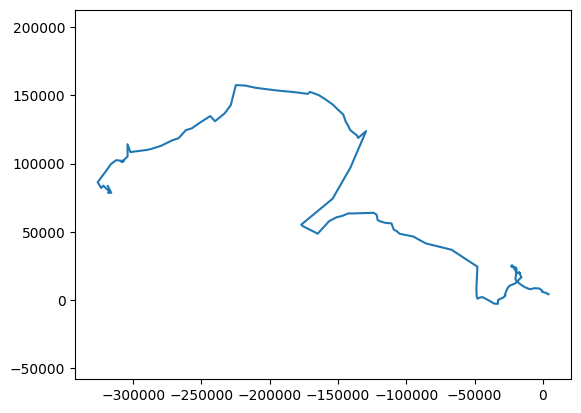

In [19]:
plt.plot(df_res.xc, df_res.yc)
plt.axis('equal')